In [1]:
from utils.paths import RAW_DIR,PREDICTIONS_DIR,PLOTS_DIR,DATABASE_DIR,MODELS_DIR
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import pickle

from preprocessing.database_manager import DatabaseManager
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from preprocessing.DescriptorEngineer import AlloyDescriptorCalculator,ElementPropertyLoader
from preprocessing.DataPreprocessor import DataPreprocessor, DataSplitter
from preprocessing.Physics import DrudeAlloyModel
from preprocessing.TernaryPlot import plot_ternary_heatmap

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
from utils.paths import DATABASE_DIR,RAW_DIR

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength
from data.splitting import DataSplitter
from data.preprocessing import prepare_train_test

from data.Descriptors import AlloyDescriptorCalculator


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler,RobustScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    WhiteKernel,
    ConstantKernel as C,
    RationalQuadratic
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Load data
1. Experimental data
2. Resistivity calculation using ANN

In [2]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge ---
df_merged = merge_data(df_optical, df_comp)
# --- Filter ---
tern_1550 = filter_by_wavelength(df_merged, 1552.0)
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[['ID','resistivity']])
# All space
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


splitting method selection based on the composition
1. Radom splitting
2. CLuster-based splitting

In [3]:
X = tern_1550[['Cu','Ni','Al','resistivity']].copy()
y = tern_1550['e2'].copy()

splitter = DataSplitter(
    test_size=0.2,
    random_state=42,
    split_method="cluster",
    n_clusters=5
)

split_dict = splitter.split(X, y)

Load the descriptors

In [4]:
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "atomic_radius": ["avg","mismatch", "range"],
    "metallic_radius": ["avg","mismatch", "range"],
    "electronegativity_pauling": ["avg","mismatch", "range"],
    "electronegativity_allen": ["avg","mismatch", "range"],
    "valence_electrons": ["avg","mismatch", "range"],
    "density": ["avg","mismatch","range"],
    "electron_affinity": ["avg", "mismatch", "range"],
    "ionization_energy_1": ["avg","mismatch", "range"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

In [8]:
y_train = split_dict['y_train']
y_test = split_dict['y_test']

Gaussian Process Pipeline

In [23]:

# ---------------------------- Base kernel ----------------------------
kernels = [
    C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1)),

    C(1.0, (1e-3, 1e3)) * Matern(
        length_scale=1.0,
        length_scale_bounds=(1e-2, 1e2),
        nu=1.5
    ) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1)),

    C(1.0, (1e-3, 1e3)) * Matern(
        length_scale=1.0,
        length_scale_bounds=(1e-2, 1e2),
        nu=2.5
    ) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1)),

    C(1.0, (1e-3, 1e3)) * RationalQuadratic(
        length_scale=1.0,
        alpha=1.0
    ) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e1)),
]

In [25]:
# ---------------------------- Pipeline ----------------------------
gp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gp", GaussianProcessRegressor(
        normalize_y=True,
        n_restarts_optimizer=5,
        random_state=42
    ))
])

param_grid = {
    "scaler": [
        StandardScaler(),
        MinMaxScaler(),
        "passthrough"
    ],
    "gp__kernel": kernels,
    "gp__alpha": [1e-8, 1e-6, 1e-4]
}

In [28]:
# ---------------------------- Cross-Validation ----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------- GridSearch ----------------------------------
grid = GridSearchCV(
    estimator=gp_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_leve

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scale

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_le

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Us

[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.4s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.4s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.3s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.3s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.3s
[CV] END gp__alpha=1e-0

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/

[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.3s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxS

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Us

[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time= 

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.3s


/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.4s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.5s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.4s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.5s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.5s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.4s


/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.6s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.6s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.4s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.5s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.3s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Us

[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-06,

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/U

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-06, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Use

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05)

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Use

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noi

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Use

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/U

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.3s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s


/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'gp__alpha': [1e-08, 1e-06, ...], 'gp__kernel': [1**2 * RBF(le...e_level=1e-05), 1**2 * Matern...e_level=1e-05), ...], 'scaler': [StandardScaler(), MinMaxScaler(), ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


In [30]:
print("Best score (CV R2):", -grid.best_score_)
print("Best params:")
print(grid.best_params_)

best_model = grid.best_estimator_

Best score (CV R2): 0.6934929066937228
Best params:
{'gp__alpha': 0.0001, 'gp__kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), 'scaler': MinMaxScaler()}


In [32]:
best_model = grid.best_estimator_
best_model.score(x_test, y_test)

y_pred = best_model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 11.9048
MAE:  8.4410
R2:   0.5187


Permutation to see the importance of the features in the model

In [33]:
result = permutation_importance(
    best_model,
    x_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

In [34]:
feature_names = x_test.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

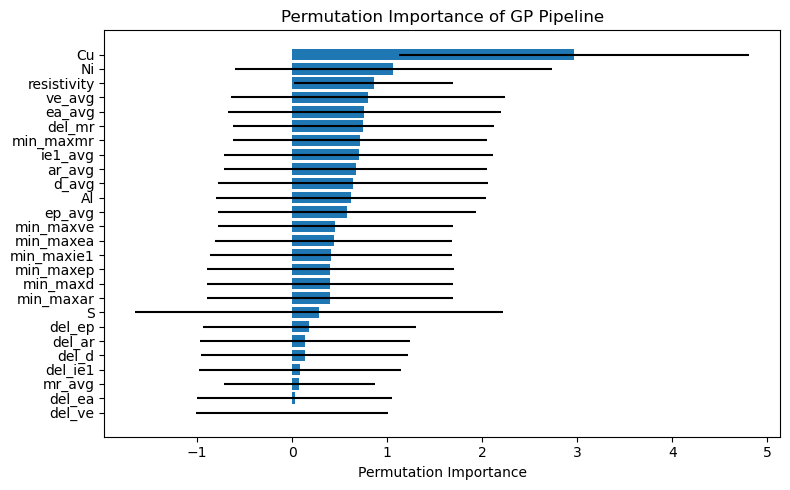

In [35]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance_mean"][::-1],
    xerr=importance_df["importance_std"][::-1]
)
plt.xlabel("Permutation Importance")
plt.title("Permutation Importance of GP Pipeline")
plt.tight_layout()
plt.show()

In [16]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc = AlloyDescriptorCalculator(elem_props=elem_props)

X_train, X_test, y_train, y_test, scaler = prepare_train_test(
    split_dict=split_dict,
    calculator=calc,
    feature_cols=["r", "del_r", "del_EN", "S", "VEC"],
    scaler=MinMaxScaler()
)

In [26]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc = AlloyDescriptorCalculator(elem_props=elem_props)
dp = DataPreprocessor()

In [44]:
X = tern_1550[['Cu','Ni','Al']].copy()
y = tern_1550['e2'].copy()

In [45]:
splitter = DataSplitter(
    test_size=0.2,
    random_state=42,
    split_method="random"
)

random_split = splitter.split_training(X, y)

splitter = DataSplitter(
    test_size=0.05,
    random_state=42,
    split_method="cluster",
    n_clusters =6,
    cluster_feature_start= 0
)

cluster_split = splitter.split_training(X, y)

In [46]:
feature_cols = ['r','del_r','del_EN','S','VEC']

x_train_rd, x_test_rd, y_train_rd, y_test_rd,scaler_rd = dp.train_test(
    random_split,
    calc,
    feature_cols,
    scaler = None
)

x_train_cl, x_test_cl, y_train_cl, y_test_cl,scaler_cl = dp.train_test(
    cluster_split,
    calc,
    feature_cols,
    scaler = None
)

Experimental data GP - Random splitting

In [37]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
)

gpr_nt_ran = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_ran.fit(x_train_rd, y_train_rd)
print("Learned kernel:", gpr_nt_ran.kernel_)

Learned kernel: 0.721**2 * Matern(length_scale=0.802, nu=2.5) + WhiteKernel(noise_level=0.412)


In [38]:
comp_cols = ['Cu','Ni','Al']
x_all = comp_space[['Cu','Ni','Al']]
df_pred_rd, error_rd = dp.gp_predict_and_errors(calc,x_all,gpr_nt_ran,scaler_rd,x_test_rd,y_test_rd,feature_cols)

df1 = random_split['X_test_split'].reset_index(drop=True)
df1 = df1*100
df2 = error_rd['df_residuals'].reset_index(drop=True)
df_test_rd = pd.concat([df1,df2], axis=1)

Plots [Predicted plot and erro plot]

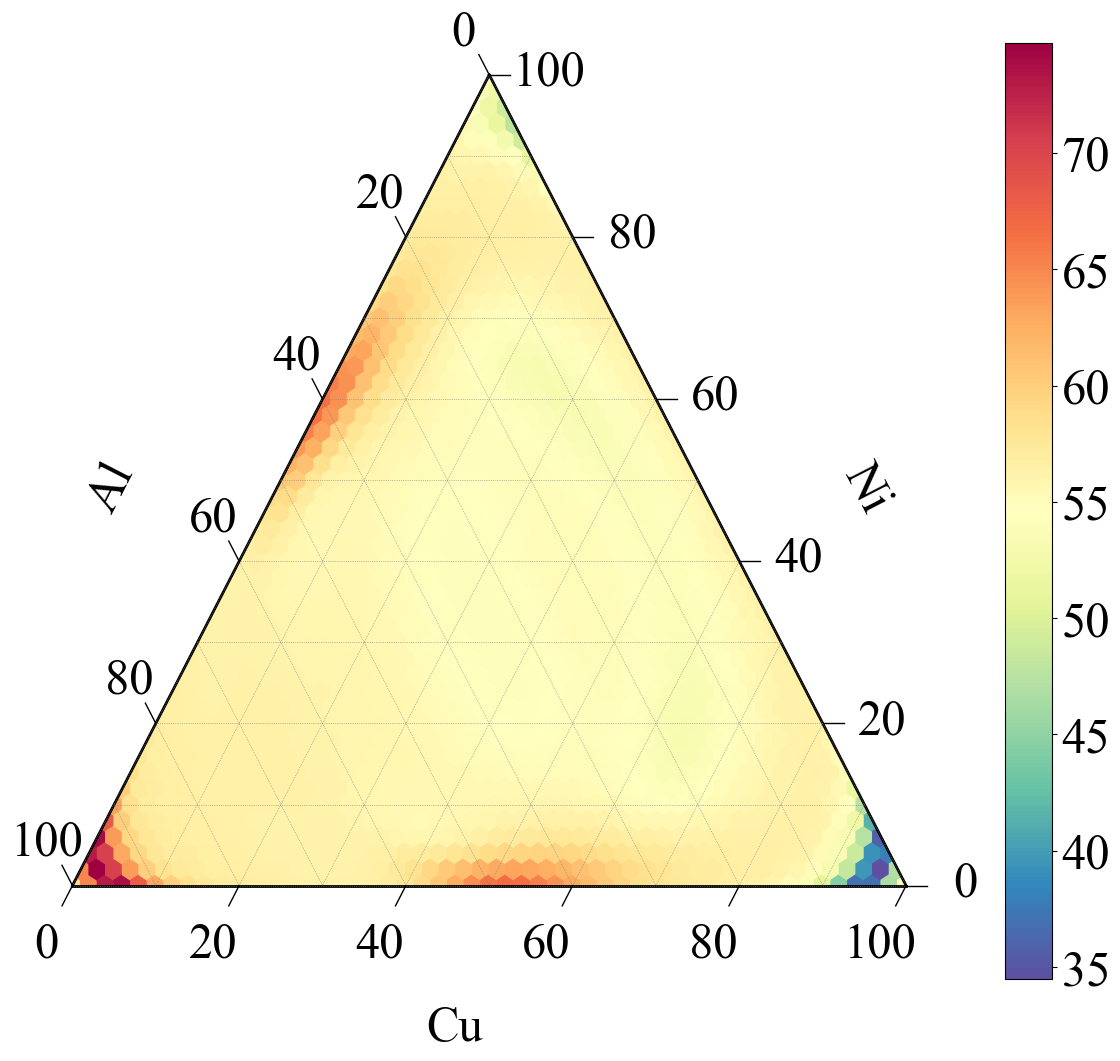

In [40]:
df_pred_rd[comp_cols] = df_pred_rd[comp_cols]*100
fig, tax = plot_ternary_heatmap(
    df=df_pred_rd,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

#fig.savefig(PLOTS_DIR/"ternary_PG_Random_split.svg", bbox_inches="tight")

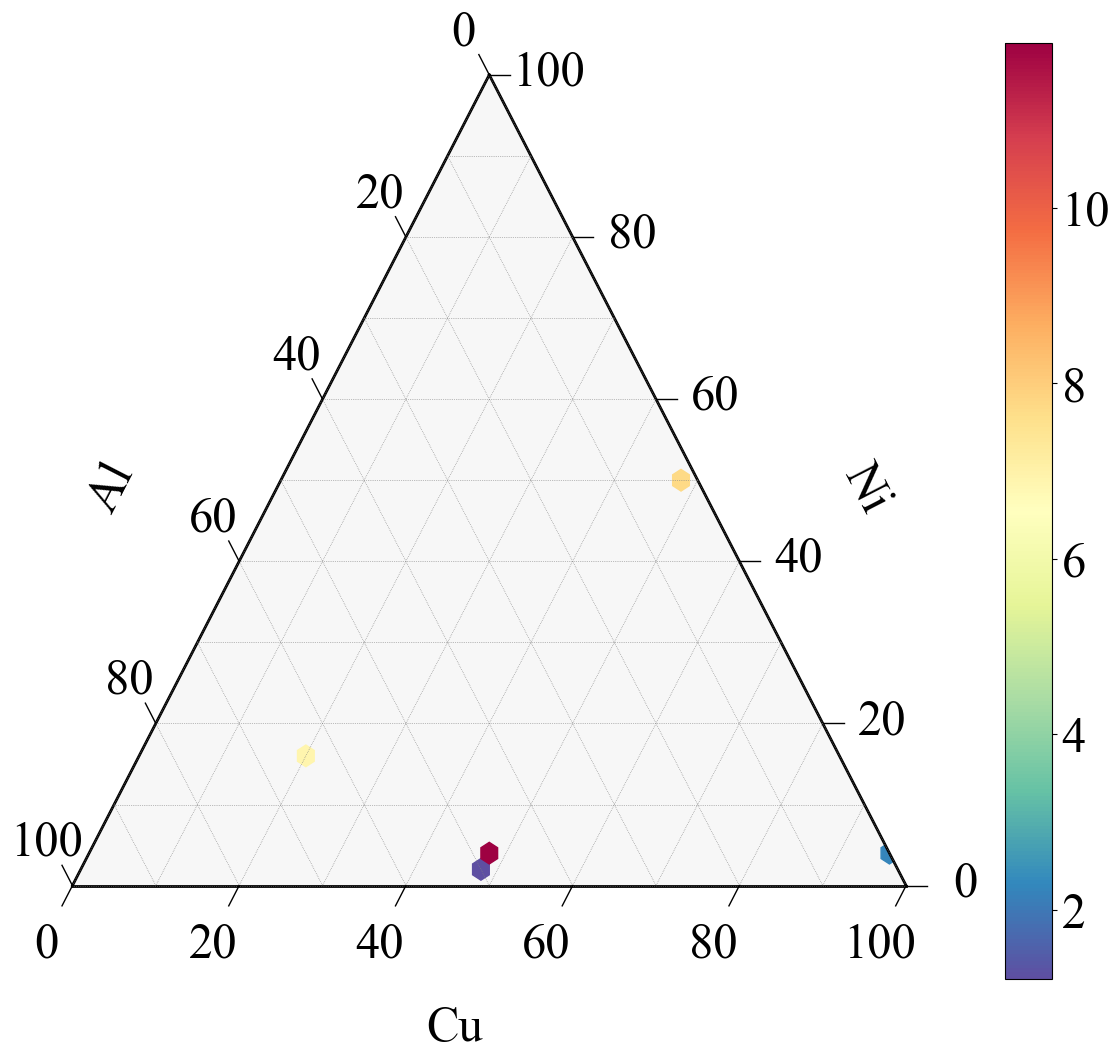

/var/folders/kk/7h_k8hgd46ld6cx6qw3lkcpc0000gn/T/ipykernel_67301/2246177404.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [41]:
fig, tax = plot_ternary_heatmap(
    df=df_test_rd,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.show()
#fig.savefig(PLOTS_DIR/"ternary_GP_error_rand_split.svg", bbox_inches="tight")

Experimental data GP - Kmeans splitting

In [30]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gpr_nt_clus = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_clus.fit(x_train_cl, y_train_cl)
print("Learned kernel:", gpr_nt_clus.kernel_)

Learned kernel: 0.947**2 * Matern(length_scale=3.38, nu=2.5) + WhiteKernel(noise_level=0.434)


In [31]:
comp_cols = ['Cu','Ni','Al']
x_all = comp_space[['Cu','Ni','Al']]
df_pred_cl, error_cl = dp.gp_predict_and_errors(calc,x_all,gpr_nt_clus,scaler_cl,x_test_cl,y_test_cl,feature_cols)

df1 = cluster_split['X_test_split'].reset_index(drop=True)
df1 = df1*100
df2 = error_cl['df_residuals'].reset_index(drop=True)
df_test_cl = pd.concat([df1,df2], axis=1)

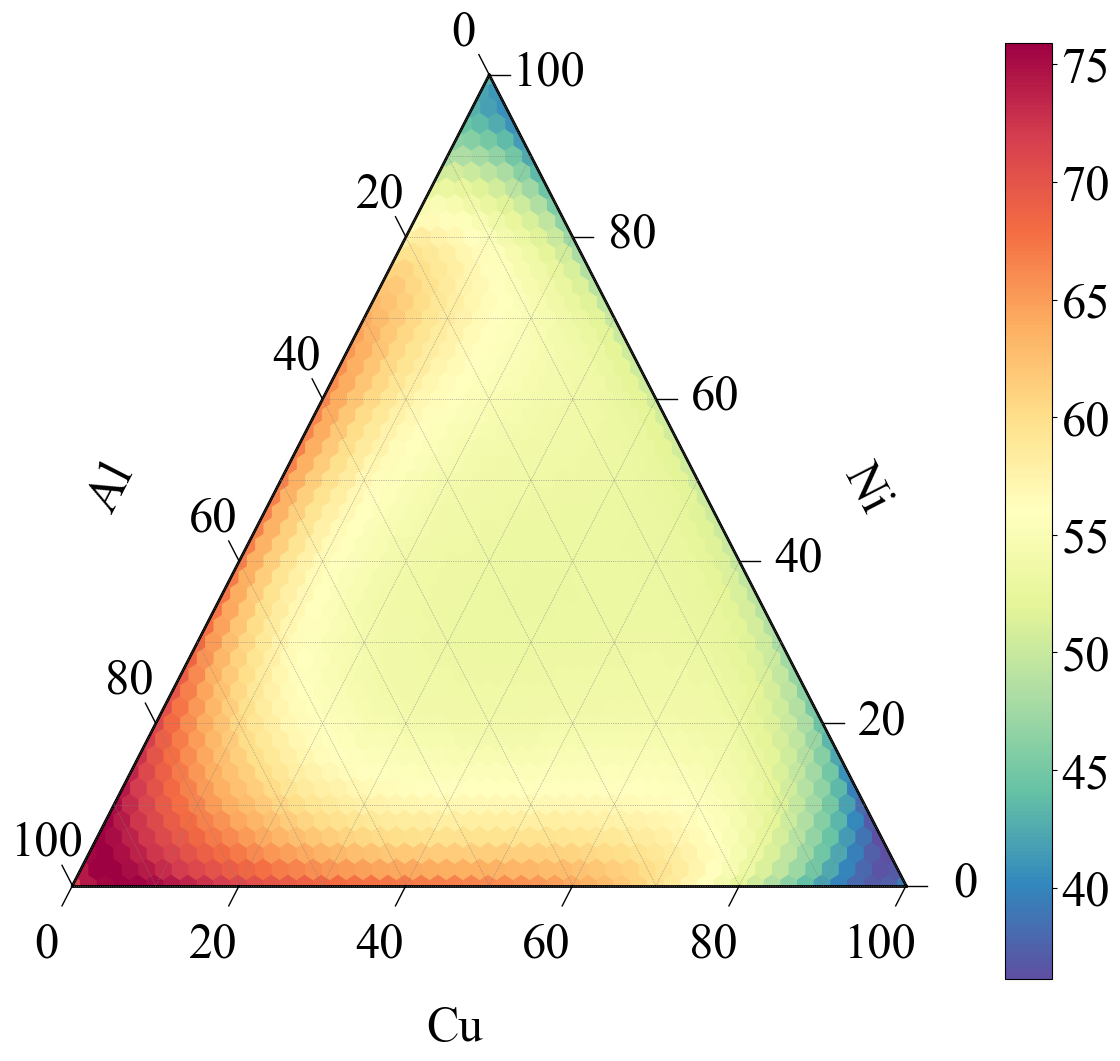

In [34]:
df_pred_cl[comp_cols] = df_pred_cl[comp_cols]*100
fig, tax = plot_ternary_heatmap(
    df=df_pred_cl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

fig.savefig(PLOTS_DIR/"ternary_PG_cluster_split.svg", bbox_inches="tight")

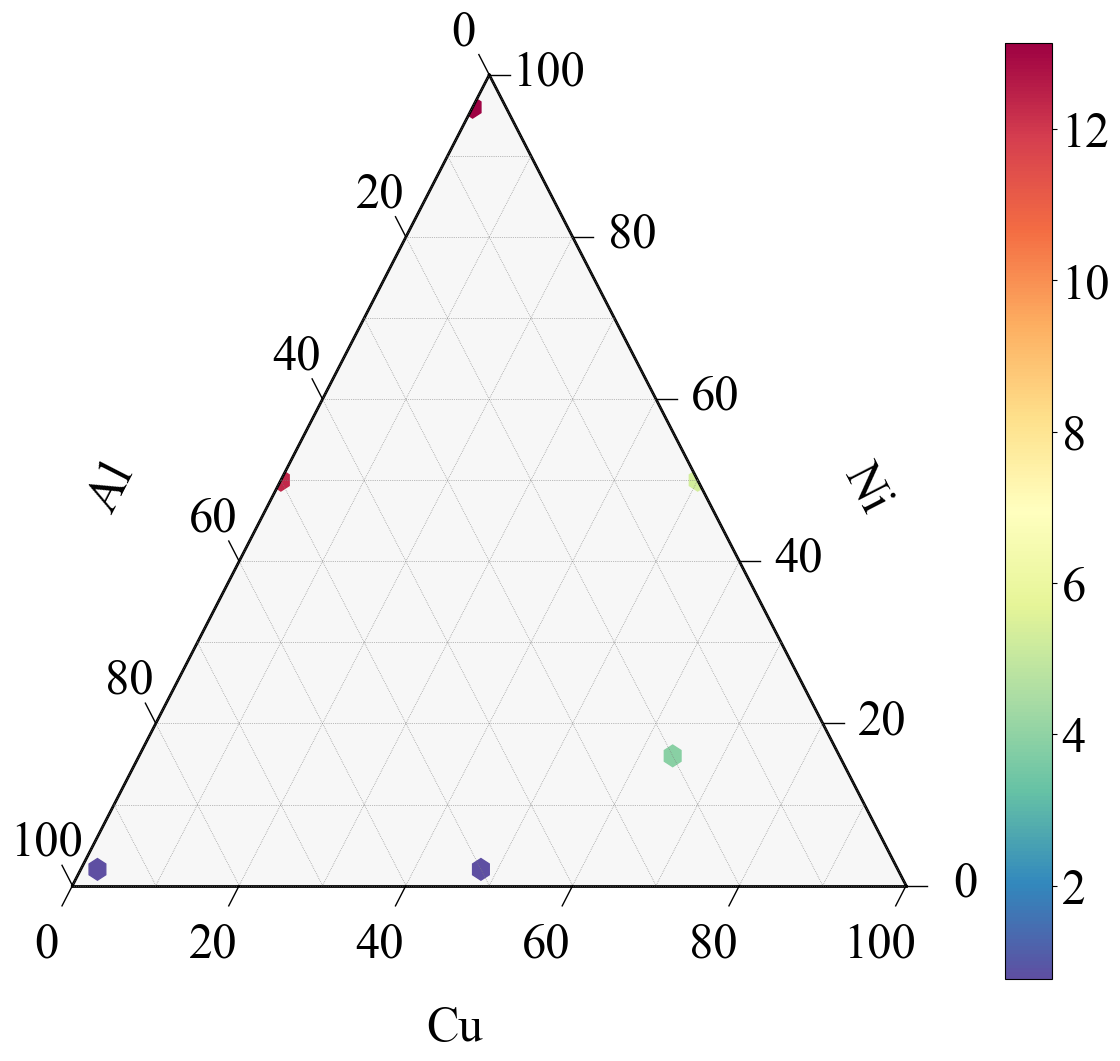

In [35]:
fig, tax = plot_ternary_heatmap(
    df=df_test_cl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_PG_cluster_split_error.svg", bbox_inches="tight")

Gaussian Process Resistivity  variable addition

In [36]:
comp_cols = ['Cu','Ni','Al']

exp_resistivity = pd.read_pickle(PREDICTIONS_DIR/'ANN_Predictions/experimental_resis_prediction.pkl')
exp_resistivity['resistivity'] = exp_resistivity['resistivity'] *1e-8
exp_resis_prediction = exp_resistivity[['Cu','Ni','Al','resistivity']]

In [37]:
cluster_split['X_train_split'] = cluster_split['X_train_split'].merge(exp_resistivity[comp_cols+['resistivity']], on=comp_cols, how='left')
cluster_split['X_test_split'] = cluster_split['X_test_split'].merge(exp_resistivity[comp_cols+['resistivity']], on=comp_cols, how='left')

In [38]:
feature_cols = ['Cu','Ni','Al','r','del_r','del_EN','S','VEC','resistivity']
x_train_cl, x_test_cl, y_train_cl, y_test_cl,scaler_cl = dp.train_test(
    cluster_split,
    calc,
    feature_cols,
    scaler = None
)

In [39]:
# Fit GP on residuals
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gp_resistivity = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)
gp_resistivity.fit(x_train_cl, y_train_cl)
print("Learned kernel:", gp_resistivity.kernel_)

Learned kernel: 0.917**2 * Matern(length_scale=2.43, nu=2.5) + WhiteKernel(noise_level=0.353)


In [40]:
y_resis_pred, y_resis_std = gp_resistivity.predict(x_test_cl, return_std=True)

In [41]:
## Error calculation
# Metrics
mse_res = mean_squared_error(cluster_split['y_test'], y_resis_pred)
rmse_res = np.sqrt(mse_res)
r2_res = r2_score(cluster_split['y_test'], y_resis_pred)

print("Residual GP Performance:")
print(f"MSE:  {mse_res:.4f}")
print(f"RMSE: {rmse_res:.4f}")
print(f"R2:   {r2_res}")

Residual GP Performance:
MSE:  39.0916
RMSE: 6.2523
R2:   0.4498416317904188


Gaussina Process Residual Approach

In [60]:
exp_resistivity = pd.read_pickle(PREDICTIONS_DIR/'ANN_Predictions/experimental_resis_prediction.pkl')
exp_resistivity['resistivity'] = exp_resistivity['resistivity'] *1e-8
exp_resis_prediction = exp_resistivity[['Cu','Ni','Al','resistivity']]

comp_cols = ['Cu','Ni','Al']
X_physics_train = cluster_split['X_train_split'].merge(exp_resistivity[comp_cols+['resistivity']], on=comp_cols, how='left')
X_physics_train = X_physics_train[X_physics_train['resistivity'] >= 0]

Gaussian process Residual Approach with XGBoost + selected data

In [62]:
# Drude model class for e2 calculation
elem_cols = ["Cu","Al","Ni"]
ne_pure = [8.47e28,18.1e28,5.64e28]
drude = DrudeAlloyModel(elem_cols=elem_cols,ne_pure=ne_pure,wavelength_unit='nm')

df_physics_train = drude.predict_dataframe(df =X_physics_train,rho_col='resistivity',wvl=1550)

In [63]:
#. Residuals
y_phys_train = np.asarray(df_physics_train['e2_drude'])
y_res_train = cluster_split['y_train'] - y_phys_train

In [64]:
# Fit GP on residuals
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gp_res = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)
gp_res.fit(x_train_cl, y_res_train)
print("Learned kernel:", gp_res.kernel_)

Learned kernel: 0.84**2 * Matern(length_scale=0.597, nu=2.5) + WhiteKernel(noise_level=0.232)


In [67]:
X_phys_test = cluster_split['X_test_split'].merge(exp_resistivity[comp_cols+['resistivity']], on=comp_cols, how='left')
X_phys_test = X_phys_test[X_phys_test['resistivity'] >= 0]
df_physics_test = drude.predict_dataframe(df =X_phys_test,rho_col='resistivity',wvl=1550)

y_phys_test = np.asarray(df_physics_test['e2_drude'])

In [70]:
x_test_cl

array([[1.26000000e+00, 1.58730159e-02, 5.00000000e-03, 5.76282566e+00,
        1.05000000e+01],
       [1.33500000e+00, 7.11610487e-02, 1.50000000e-01, 5.76282566e+00,
        6.50000000e+00],
       [1.29550000e+00, 4.94207602e-02, 1.14930562e-01, 7.46980719e+00,
        9.26000000e+00],
       [1.35400000e+00, 5.63143207e-02, 1.45258175e-01, 6.58805353e+00,
        6.97500000e+00],
       [1.24950000e+00, 3.31408883e-02, 6.53834842e-02, 1.65045573e+00,
        9.65000000e+00],
       [1.42150000e+00, 2.62536517e-02, 6.43034797e-02, 1.93859702e+00,
        3.37500000e+00]])

In [74]:
# Predict on new points
y_res_pred, y_res_std = gp_res.predict(x_test_cl, return_std=True)
y_res_pred = y_res_pred[y_res_pred >= 0]

# Final Prediction
y_predic = y_phys_test + y_res_pred

In [75]:
y_res_pred

array([ 0.10712497, 23.41060697, 30.49686041, 21.83817666, 20.45786041])

In [55]:
error_cl

{'mae': 6.037880641770033,
 'rmse': np.float64(7.846943731316948),
 'r2': 0.13342768341711697,
 'df_residuals':       y_true     y_pred      error  error_abs    error_sq
 0  55.827915  50.487435   5.340480   5.340480   28.520725
 1  54.283161  66.624906 -12.341745  12.341745  152.318678
 2  50.837952  54.706914  -3.868962   3.868962   14.968869
 3  62.303177  63.068210  -0.765033   0.765033    0.585276
 4  56.649986  43.518098  13.131888  13.131888  172.446494
 5  76.665421  75.886246   0.779175   0.779175    0.607113}

In [76]:
y_predic

array([ 25.16603232, 128.22774835,  60.94700776,  86.87479796,
        73.17992248])

In [77]:
## Error calculation
# Metrics
mse_res = mean_squared_error(cluster_split['y_test'], y_predic)
rmse_res = np.sqrt(mse_res)
r2_res = r2_score(cluster_split['y_test'], y_predic)

print("Residual GP Performance:")
print(f"MSE:  {mse_res:.4f}")
print(f"RMSE: {rmse_res:.4f}")
print(f"R2:   {r2_res:.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [6, 5]

GPy module installation

In [ ]:
import GPy
# Mean function
mf = GPy.core.Mapping (input_dim=1, output_dim=1)
mf.f = lambda X: np.sin(X)
mf.update_gradients = lambda dL_dF, X:None

# Kernel
k = GPy.kern.RBF(input_dim=1)

#GP model with custom mean
m =  GPy.models.GPRegression(X, Y, kernel=k, mean_function=mf)